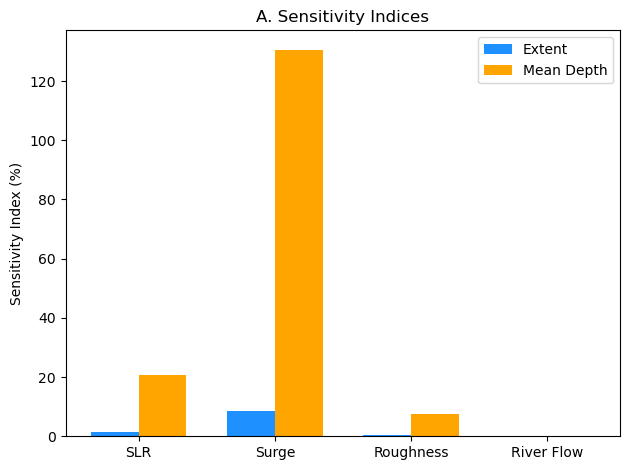

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Threshold for inundation (in meters)
THRESHOLD = 0.1

# --- File paths ---
ref_file = r"D:\Phd Research\sim_depth_100yr.tif"
slr_minus = r"D:\Phd Research\sim_depth_100yr_0.8SLR.tif"
slr_plus = r"D:\Phd Research\sim_depth_100yr_1.2SLR.tif"
surge_minus = r"D:\Phd Research\sim_depth_100yr_surge_M10.tif"
surge_plus = r"D:\Phd Research\sim_depth_100yr_surge_P10.tif"
rough_minus = r"D:\Phd Research\sim_depth_100yr_surge_M20_Mannings.tif"
rough_plus = r"D:\Phd Research\sim_depth_100yr_surge_P20_Mannings.tif"
flow_minus = r"D:\Phd Research\sim_depth_100yr_surge_Q_M20.tif"
flow_plus = r"D:\Phd Research\sim_depth_100yr_surge_Q_P20.tif"

# --- Function to compute extent and mean depth ---
def compute_extent_mean_depth(file):
    with rasterio.open(file) as src:
        data = src.read(1, masked=True)
        inundated = data > THRESHOLD
        extent = np.sum(inundated)
        mean_depth = data[inundated].mean() if extent > 0 else 0
    return extent, mean_depth

# --- Reference values ---
extent_0, mean_depth_0 = compute_extent_mean_depth(ref_file)

# --- Perturbation percentages ---
perturbations = {
    'SLR': [slr_minus, slr_plus, 0.2],
    'Surge': [surge_minus, surge_plus, 0.1],
    'Roughness': [rough_minus, rough_plus, 0.2],
    'River Flow': [flow_minus, flow_plus, 0.2]
}

extent_si = []
depth_si = []

# --- Sensitivity Index Calculation ---
for param, (file_minus, file_plus, delta_p) in perturbations.items():
    extent_minus, depth_minus = compute_extent_mean_depth(file_minus)
    extent_plus, depth_plus = compute_extent_mean_depth(file_plus)

    # ΔE and ΔP
    delta_extent = (extent_plus - extent_minus) / 2
    delta_depth = (depth_plus - depth_minus) / 2

    # Normalized sensitivity
    si_extent = (delta_extent / extent_0) / delta_p
    si_depth = (delta_depth / mean_depth_0) / delta_p

    extent_si.append(si_extent * 100)  # Convert to %
    depth_si.append(si_depth * 100)

# --- Plotting ---
labels = list(perturbations.keys())
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
bars1 = ax.bar(x - width/2, extent_si, width, label='Extent', color='dodgerblue')
bars2 = ax.bar(x + width/2, depth_si, width, label='Mean Depth', color='orange')

ax.set_ylabel('Sensitivity Index (%)')
ax.set_title('A. Sensitivity Indices')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.tight_layout()
plt.show()


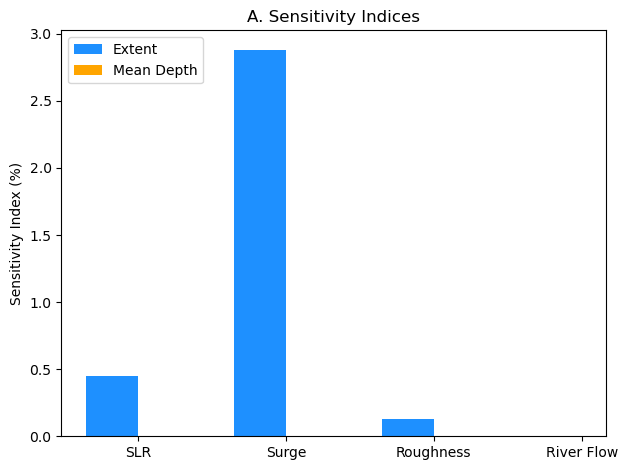

In [3]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os

# --- Configurations ---
THRESHOLD = 0.3  # Inundation threshold in meters

# Paths
boundary_zip = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
shapefile_extract_path = r"D:\Phd Research\GIS\Shape\unzipped"
ref_file = r"D:\Phd Research\sim_depth_100yr.tif"
slr_minus = r"D:\Phd Research\sim_depth_100yr_0.8SLR.tif"
slr_plus = r"D:\Phd Research\sim_depth_100yr_1.2SLR.tif"
surge_minus = r"D:\Phd Research\sim_depth_100yr_surge_M10.tif"
surge_plus = r"D:\Phd Research\sim_depth_100yr_surge_P10.tif"
rough_minus = r"D:\Phd Research\sim_depth_100yr_surge_M20_Mannings.tif"
rough_plus = r"D:\Phd Research\sim_depth_100yr_surge_P20_Mannings.tif"
flow_minus = r"D:\Phd Research\sim_depth_100yr_surge_Q_M20.tif"
flow_plus = r"D:\Phd Research\sim_depth_100yr_surge_Q_P20.tif"

# --- Extract shapefile from ZIP ---
with zipfile.ZipFile(boundary_zip, 'r') as zip_ref:
    zip_ref.extractall(shapefile_extract_path)

# Find the .shp file inside the extracted contents
shapefile = [os.path.join(shapefile_extract_path, f) for f in os.listdir(shapefile_extract_path) if f.endswith(".shp")][0]

# Load shapefile
gdf = gpd.read_file(shapefile)
geoms = gdf.geometry.values

# --- Function to compute extent and mean depth within boundary ---
def compute_extent_mean_depth_masked(raster_path):
    with rasterio.open(raster_path) as src:
        out_image, out_transform = mask(src, geoms, crop=True)
        data = out_image[0]
        masked_data = np.ma.masked_where(data <= THRESHOLD, data)
        extent = np.sum(masked_data.mask == False)
        mean_depth = masked_data.mean() if extent > 0 else 0
    return extent, mean_depth

# --- Reference values ---
extent_0, mean_depth_0 = compute_extent_mean_depth_masked(ref_file)

# --- Perturbation percentages ---
perturbations = {
    'SLR': [slr_minus, slr_plus, 0.2],
    'Surge': [surge_minus, surge_plus, 0.1],
    'Roughness': [rough_minus, rough_plus, 0.2],
    'River Flow': [flow_minus, flow_plus, 0.2]
}

extent_si = []
depth_si = []

# --- Sensitivity Index Calculation ---
for param, (file_minus, file_plus, delta_p) in perturbations.items():
    extent_minus, depth_minus = compute_extent_mean_depth_masked(file_minus)
    extent_plus, depth_plus = compute_extent_mean_depth_masked(file_plus)

    # ΔE and ΔP
    delta_extent = (extent_plus - extent_minus) / 2
    delta_depth = (depth_plus - depth_minus) / 2

    # Normalized sensitivity
    si_extent = (delta_extent / extent_0) / delta_p
    si_depth = (delta_depth / mean_depth_0) / delta_p

    extent_si.append(si_extent * 100)  # Convert to %
    depth_si.append(si_depth * 100)

# --- Plotting ---
labels = list(perturbations.keys())
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
bars1 = ax.bar(x - width/2, extent_si, width, label='Extent', color='dodgerblue')
bars2 = ax.bar(x + width/2, depth_si, width, label='Mean Depth', color='orange')

ax.set_ylabel('Sensitivity Index (%)')
ax.set_title('A. Sensitivity Indices')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.tight_layout()
plt.show()


Reference Extent: 1967300, Reference Mean Depth: nan

SLR Sensitivity:
  Extent (-): 1966326, Extent (+): 1968283
  ΔExtent: 978.5, SI (Extent): 0.25 %
  Mean Depth (-): nan, (+): nan
  ΔDepth: nan, SI (Depth): nan %

Surge Sensitivity:
  Extent (-): 1963011, Extent (+): 1969043
  ΔExtent: 3016.0, SI (Extent): 1.53 %
  Mean Depth (-): nan, (+): nan
  ΔDepth: nan, SI (Depth): nan %

Roughness Sensitivity:
  Extent (-): 1967115, Extent (+): 1967814
  ΔExtent: 349.5, SI (Extent): 0.09 %
  Mean Depth (-): nan, (+): nan
  ΔDepth: nan, SI (Depth): nan %


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values



River Flow Sensitivity:
  Extent (-): 1967300, Extent (+): 1967300
  ΔExtent: 0.0, SI (Extent): 0.00 %
  Mean Depth (-): nan, (+): nan
  ΔDepth: nan, SI (Depth): nan %


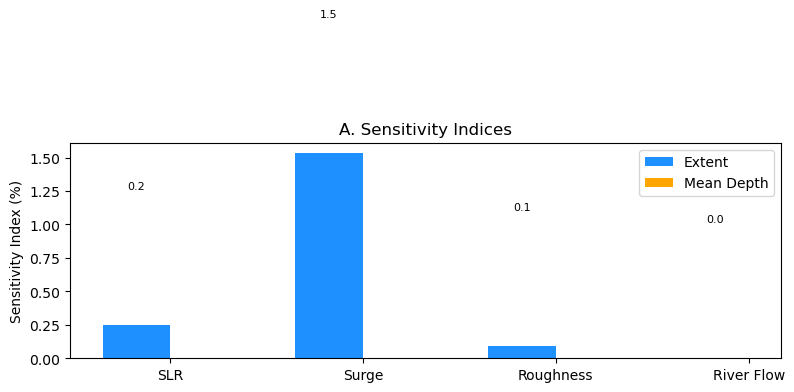

In [4]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os

# Inundation depth threshold (in meters)
THRESHOLD = 0.1

# --- File paths ---
boundary_zip = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
shapefile_extract_path = r"D:\Phd Research\GIS\Shape\unzipped"

# Water depth rasters
ref_file = r"D:\Phd Research\sim_depth_100yr.tif"
slr_minus = r"D:\Phd Research\sim_depth_100yr_0.8SLR.tif"
slr_plus = r"D:\Phd Research\sim_depth_100yr_1.2SLR.tif"
surge_minus = r"D:\Phd Research\sim_depth_100yr_surge_M10.tif"
surge_plus = r"D:\Phd Research\sim_depth_100yr_surge_P10.tif"
rough_minus = r"D:\Phd Research\sim_depth_100yr_surge_M20_Mannings.tif"
rough_plus = r"D:\Phd Research\sim_depth_100yr_surge_P20_Mannings.tif"
flow_minus = r"D:\Phd Research\sim_depth_100yr_surge_Q_M20.tif"
flow_plus = r"D:\Phd Research\sim_depth_100yr_surge_Q_P20.tif"

# --- Extract shapefile from ZIP ---
with zipfile.ZipFile(boundary_zip, 'r') as zip_ref:
    zip_ref.extractall(shapefile_extract_path)

# Find the .shp file inside the extracted contents
shapefile = [os.path.join(shapefile_extract_path, f) for f in os.listdir(shapefile_extract_path) if f.endswith(".shp")][0]

# Load shapefile geometry
gdf = gpd.read_file(shapefile)
geoms = gdf.geometry.values

# --- Function to compute extent and mean depth within the shapefile boundary ---
def compute_extent_mean_depth_masked(raster_path):
    with rasterio.open(raster_path) as src:
        out_image, out_transform = mask(src, geoms, crop=True)
        data = out_image[0]
        masked_data = np.ma.masked_where(data <= THRESHOLD, data)
        extent = np.sum(masked_data.mask == False)
        mean_depth = masked_data.mean() if extent > 0 else 0
    return extent, mean_depth

# --- Reference values ---
extent_0, mean_depth_0 = compute_extent_mean_depth_masked(ref_file)
print(f"Reference Extent: {extent_0}, Reference Mean Depth: {mean_depth_0:.4f}")

# --- Perturbation definitions ---
perturbations = {
    'SLR': [slr_minus, slr_plus, 0.2],
    'Surge': [surge_minus, surge_plus, 0.1],
    'Roughness': [rough_minus, rough_plus, 0.2],
    'River Flow': [flow_minus, flow_plus, 0.2]
}

extent_si = []
depth_si = []

# --- Compute sensitivity index for each parameter ---
for param, (file_minus, file_plus, delta_p) in perturbations.items():
    extent_minus, depth_minus = compute_extent_mean_depth_masked(file_minus)
    extent_plus, depth_plus = compute_extent_mean_depth_masked(file_plus)

    delta_extent = (extent_plus - extent_minus) / 2
    delta_depth = (depth_plus - depth_minus) / 2

    si_extent = (delta_extent / extent_0) / delta_p
    si_depth = (delta_depth / mean_depth_0) / delta_p

    extent_si.append(si_extent * 100)
    depth_si.append(si_depth * 100)

    # Debug output to understand large SI
    print(f"\n{param} Sensitivity:")
    print(f"  Extent (-): {extent_minus}, Extent (+): {extent_plus}")
    print(f"  ΔExtent: {delta_extent}, SI (Extent): {si_extent * 100:.2f} %")
    print(f"  Mean Depth (-): {depth_minus:.4f}, (+): {depth_plus:.4f}")
    print(f"  ΔDepth: {delta_depth:.4f}, SI (Depth): {si_depth * 100:.2f} %")

# --- Plotting ---
labels = list(perturbations.keys())
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, extent_si, width, label='Extent', color='dodgerblue')
bars2 = ax.bar(x + width/2, depth_si, width, label='Mean Depth', color='orange')

ax.set_ylabel('Sensitivity Index (%)')
ax.set_title('A. Sensitivity Indices')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Annotate bars (optional)
for bar in bars1 + bars2:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


Reference extent: 13837.280 km² | Reference mean depth: 4.9344 m (threshold > 0.1 m)

SLR sensitivity (Δp = 20%):
  Extent: minus=13798.320 km², plus=13876.600 km² -> SI_extent=1.41%
  Mean D: minus=4.7258 m,   plus=5.1376 m   -> SI_depth=20.86%

Surge sensitivity (Δp = 10%):
  Extent: minus=13665.720 km², plus=13907.000 km² -> SI_extent=8.72%
  Mean D: minus=4.2485 m,   plus=5.5481 m   -> SI_depth=131.69%

Roughness sensitivity (Δp = 20%):
  Extent: minus=13829.880 km², plus=13857.840 km² -> SI_extent=0.51%
  Mean D: minus=4.8587 m,   plus=5.0086 m   -> SI_depth=7.59%

River Flow sensitivity (Δp = 20%):
  Extent: minus=13837.280 km², plus=13837.280 km² -> SI_extent=0.00%
  Mean D: minus=4.9344 m,   plus=4.9344 m   -> SI_depth=0.00%

=== Sensitivity Index Summary ===
    Driver  SI_extent_%  SI_mean_depth_%  Extent_minus_km2  Extent_plus_km2  MeanDepth_minus_m  MeanDepth_plus_m
       SLR     1.414295        20.861404          13798.32         13876.60           4.725848          5.137

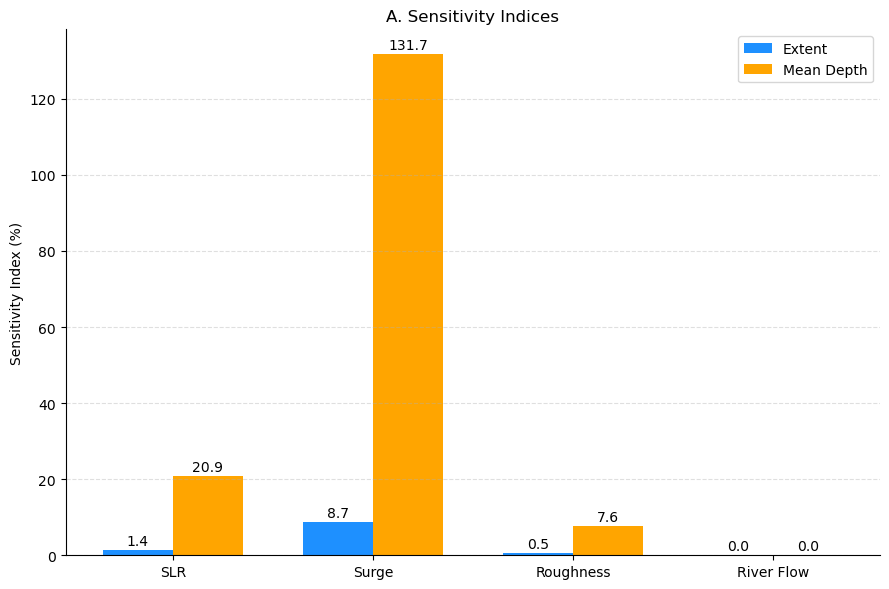

In [8]:
import os
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ====================== USER INPUTS ======================
# Inundation depth threshold (m): cells <= THRESHOLD are considered dry
THRESHOLD = 0.1

# Boundary zip (GeoPandas can read from zip directly using "zip://")
boundary_zip = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Water depth rasters
ref_file   = r"D:\Phd Research\sim_depth_100yr.tif"

slr_minus  = r"D:\Phd Research\sim_depth_100yr_0.8SLR.tif"      # 20% less SLR
slr_plus   = r"D:\Phd Research\sim_depth_100yr_1.2SLR.tif"      # 20% more SLR

surge_minus = r"D:\Phd Research\sim_depth_100yr_surge_M10.tif"  # 10% less surge height
surge_plus  = r"D:\Phd Research\sim_depth_100yr_surge_P10.tif"  # 10% more surge height

rough_minus = r"D:\Phd Research\sim_depth_100yr_surge_M20_Mannings.tif" # 20% less Manning's M
rough_plus  = r"D:\Phd Research\sim_depth_100yr_surge_P20_Mannings.tif" # 20% more Manning's M

flow_minus  = r"D:\Phd Research\sim_depth_100yr_surge_Q_M20.tif" # 20% less inland discharge
flow_plus   = r"D:\Phd Research\sim_depth_100yr_surge_Q_P20.tif" # 20% more inland discharge

# Percentage perturbations for central difference normalization (as fractions)
# e.g., 0.2 = 20%, 0.1 = 10%
PERTURB = {
    "SLR":        0.2,
    "Surge":      0.1,
    "Roughness":  0.2,
    "River Flow": 0.2,
}

# Presentation
TITLE = "Sensitivity Indices"
# ========================================================


# ---------- Helper: read boundary from zip (or fallback) ----------
def read_boundary_from_zip(zip_path: str) -> gpd.GeoDataFrame:
    # Most reliable way in GeoPandas is to prefix with "zip://"
    # If your .zip contains multiple layers, the first will be read.
    try:
        gdf = gpd.read_file(f"zip://{zip_path}")
        return gdf
    except Exception:
        # Fallback: try reading directly (some environments allow passing .zip)
        return gpd.read_file(zip_path)

# ---------- Core computation for one raster ----------
def compute_extent_and_mean_depth(raster_path: str, boundary_gdf: gpd.GeoDataFrame, threshold: float):
    """
    Returns:
      extent_area_km2: flooded area in km² (depth > threshold)
      mean_depth: mean depth (m) over flooded cells only
    """
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        # Reproject boundary to raster CRS
        boundary_proj = boundary_gdf.to_crs(src.crs)

        # Clip raster to boundary
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        data = out_img[0].astype("float64")
        nodata = src.nodata

    # Build mask for invalid/non-flooded cells
    m = np.zeros(data.shape, dtype=bool)
    if nodata is not None:
        m |= (data == nodata)
    m |= (~np.isfinite(data))  # NaN/Inf
    m |= (data < 0)            # negative depths are invalid
    m |= (data <= threshold)   # dry cells (<= threshold)

    masked = ma.array(data, mask=m)

    # Pixel area (m²)
    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h

    # Extent as area (km²)
    flooded_cells = masked.count()
    extent_area_km2 = (flooded_cells * cell_area_m2) / 1e6

    # Mean depth over flooded cells (avoid NaN)
    mean_depth = float(masked.mean()) if flooded_cells > 0 else 0.0

    return extent_area_km2, mean_depth

# ---------- Sensitivity Index helper ----------
def sensitivity_index_percent(base_val: float, minus_val: float, plus_val: float, delta_p_frac: float) -> float:
    """
    Central-difference sensitivity index (normalized), returned in percent.
    SI% = ((M+ - M-) / 2) / (M0 * delta_p) * 100
    Handles divide-by-zero safely by returning 0 if base is 0 or delta_p is 0.
    """
    if base_val == 0 or delta_p_frac == 0:
        return 0.0
    delta_m = (plus_val - minus_val) / 2.0
    si = (delta_m / base_val) / delta_p_frac
    return si * 100.0

# ====================== MAIN ======================
# Load boundary
boundary = read_boundary_from_zip(boundary_zip)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Set the CRS (e.g., EPSG:32614) before proceeding.")

# Reference metrics
extent_ref, depth_ref = compute_extent_and_mean_depth(ref_file, boundary, THRESHOLD)
print(f"Reference extent: {extent_ref:.3f} km² | Reference mean depth: {depth_ref:.4f} m (threshold > {THRESHOLD} m)")

# Define driver scenarios
drivers = {
    "SLR":        (slr_minus,  slr_plus,  PERTURB["SLR"]),
    "Surge":      (surge_minus, surge_plus, PERTURB["Surge"]),
    "Roughness":  (rough_minus, rough_plus, PERTURB["Roughness"]),
    "River Flow": (flow_minus,  flow_plus,  PERTURB["River Flow"]),
}

rows = []
for driver, (f_minus, f_plus, dp) in drivers.items():
    extent_minus, depth_minus = compute_extent_and_mean_depth(f_minus, boundary, THRESHOLD)
    extent_plus,  depth_plus  = compute_extent_and_mean_depth(f_plus,  boundary, THRESHOLD)

    si_extent = sensitivity_index_percent(extent_ref, extent_minus, extent_plus, dp)
    si_depth  = sensitivity_index_percent(depth_ref,  depth_minus,  depth_plus,  dp)

    rows.append({
        "Driver": driver,
        "Extent_minus_km2": extent_minus,
        "Extent_plus_km2": extent_plus,
        "MeanDepth_minus_m": depth_minus,
        "MeanDepth_plus_m": depth_plus,
        "SI_extent_%": si_extent,
        "SI_mean_depth_%": si_depth
    })

    # Debug prints
    print(f"\n{driver} sensitivity (Δp = {dp*100:.0f}%):")
    print(f"  Extent: minus={extent_minus:.3f} km², plus={extent_plus:.3f} km² -> SI_extent={si_extent:.2f}%")
    print(f"  Mean D: minus={depth_minus:.4f} m,   plus={depth_plus:.4f} m   -> SI_depth={si_depth:.2f}%")

# Results table
df = pd.DataFrame(rows)
df = df[["Driver", "SI_extent_%", "SI_mean_depth_%", "Extent_minus_km2", "Extent_plus_km2", "MeanDepth_minus_m", "MeanDepth_plus_m"]]
print("\n=== Sensitivity Index Summary ===")
print(df.to_string(index=False))

# ----- Plotting -----
labels = df["Driver"].tolist()
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))

bars1 = ax.bar(x - width/2, df["SI_extent_%"], width, label="Extent", color="dodgerblue")
bars2 = ax.bar(x + width/2, df["SI_mean_depth_%"], width, label="Mean Depth", color="orange")

ax.set_ylabel("Sensitivity Index (%)")
ax.set_title(TITLE)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Annotate bars
for bar in list(bars1) + list(bars2):
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, y + (0.5 if y >= 0 else -1.0),
            f"{y:.1f}", ha="center", va="bottom" if y >= 0 else "top", fontsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

# Save outputs
out_dir = Path.cwd()
df_path = out_dir / "sensitivity_indices_summary.csv"
fig_path = out_dir / "sensitivity_indices_plot.png"
df.to_csv(df_path, index=False)
plt.savefig(fig_path, dpi=300)
print(f"\nSaved table to: {df_path}")
print(f"Saved figure to: {fig_path}")

plt.show()


Reference: extent = 13837.280 km² | mean depth = 4.9344 m  (threshold > 0.1 m)

SLR (ΔP/P0 = 0.20):
  Extent: minus=13798.320, plus=13876.600 -> SI=0.06%
  Depth : minus=4.7258, plus=5.1376 -> SI=0.83%

Surge (ΔP/P0 = 0.10):
  Extent: minus=13665.720, plus=13907.000 -> SI=0.09%
  Depth : minus=4.2485, plus=5.5481 -> SI=1.32%

Roughness (ΔP/P0 = 0.20):
  Extent: minus=13829.880, plus=13857.840 -> SI=0.02%
  Depth : minus=4.8587, plus=5.0086 -> SI=0.30%

River Flow (ΔP/P0 = 0.20):
  Extent: minus=13837.280, plus=13837.280 -> SI=0.00%
  Depth : minus=4.9344, plus=4.9344 -> SI=0.00%

=== Sensitivity Index Summary (SI = (ΔP/P0)·(ΔE/E0)) ===
    Driver  SI_extent_%  SI_mean_depth_%  Extent_minus_km2  Extent_plus_km2  MeanDepth_minus_m  MeanDepth_plus_m
       SLR     0.056572         0.834456          13798.32         13876.60           4.725848          5.137601
     Surge     0.087185         1.316882          13665.72         13907.00           4.248513          5.548114
 Roughness     0.

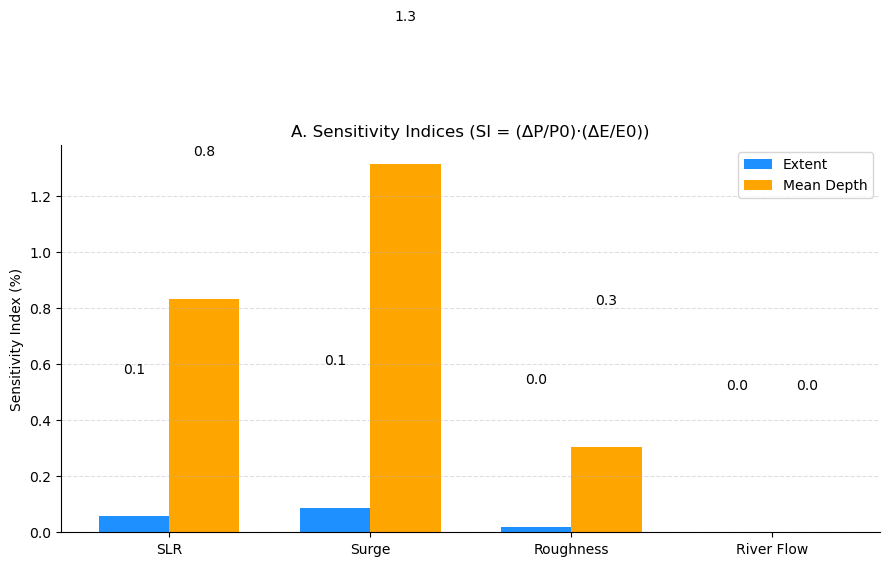

In [9]:
import os
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ====================== USER INPUTS ======================
THRESHOLD = 0.1  # meters; cells <= THRESHOLD are dry

# Boundary (GeoPandas can read zipped shapefile with "zip://")
boundary_zip = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Reference & perturbed rasters
ref_file   = r"D:\Phd Research\sim_depth_100yr.tif"

slr_minus  = r"D:\Phd Research\sim_depth_100yr_0.8SLR.tif"      # 20% less SLR
slr_plus   = r"D:\Phd Research\sim_depth_100yr_1.2SLR.tif"      # 20% more SLR

surge_minus = r"D:\Phd Research\sim_depth_100yr_surge_M10.tif"  # 10% less surge
surge_plus  = r"D:\Phd Research\sim_depth_100yr_surge_P10.tif"  # 10% more surge

rough_minus = r"D:\Phd Research\sim_depth_100yr_surge_M20_Mannings.tif" # 20% less Manning's M
rough_plus  = r"D:\Phd Research\sim_depth_100yr_surge_P20_Mannings.tif" # 20% more Manning's M

flow_minus  = r"D:\Phd Research\sim_depth_100yr_surge_Q_M20.tif" # 20% less inland discharge
flow_plus   = r"D:\Phd Research\sim_depth_100yr_surge_Q_P20.tif" # 20% more inland discharge

# Fractional parameter perturbations (ΔP/P0)
DP_FRAC = {
    "SLR":        0.20,
    "Surge":      0.10,
    "Roughness":  0.20,
    "River Flow": 0.20,
}

TITLE = "Sensitivity Indices (SI = (ΔP/P0)·(ΔE/E0))"
# ========================================================

def read_boundary_from_zip(zip_path: str) -> gpd.GeoDataFrame:
    try:
        return gpd.read_file(f"zip://{zip_path}")
    except Exception:
        return gpd.read_file(zip_path)

def compute_extent_and_mean_depth(raster_path: str, boundary_gdf: gpd.GeoDataFrame, threshold: float):
    """
    Returns:
      extent_area_km2: flooded area in km² (cells with depth > threshold)
      mean_depth: mean flooded depth in meters (over cells with depth > threshold)
    """
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        data = out_img[0].astype("float64")
        nodata = src.nodata

    # mask invalid / dry
    m = np.zeros(data.shape, dtype=bool)
    if nodata is not None:
        m |= (data == nodata)
    m |= (~np.isfinite(data))  # NaN/Inf
    m |= (data < 0)            # negative depths invalid
    m |= (data <= threshold)   # dry cells

    masked = ma.array(data, mask=m)

    # pixel area (m²) -> extent area (km²)
    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h
    flooded_cells = masked.count()
    extent_area_km2 = (flooded_cells * cell_area_m2) / 1e6

    # mean flooded depth
    mean_depth = float(masked.mean()) if flooded_cells > 0 else 0.0
    return extent_area_km2, mean_depth

def si_product_percent(E0: float, E_minus: float, E_plus: float, dp_frac: float) -> float:
    """
    SI% = (ΔP/P0) * (ΔE/E0) * 100
        where ΔE = (E_plus - E_minus) / 2  (central difference)
              ΔP/P0 = dp_frac (given for symmetric ±k%)
    Safe for E0 == 0 -> returns 0 (undefined, but avoids NaN/Inf).
    """
    if E0 == 0 or dp_frac == 0:
        return 0.0
    dE = (E_plus - E_minus) / 2.0
    return (dp_frac * (dE / E0)) * 100.0

# ------------------ MAIN ------------------
boundary = read_boundary_from_zip(boundary_zip)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Set CRS (e.g., EPSG:32614) before running.")

# Reference metrics
E0_extent, E0_depth = compute_extent_and_mean_depth(ref_file, boundary, THRESHOLD)
print(f"Reference: extent = {E0_extent:.3f} km² | mean depth = {E0_depth:.4f} m  (threshold > {THRESHOLD} m)")

drivers = {
    "SLR":        (slr_minus,  slr_plus,  DP_FRAC["SLR"]),
    "Surge":      (surge_minus, surge_plus, DP_FRAC["Surge"]),
    "Roughness":  (rough_minus, rough_plus, DP_FRAC["Roughness"]),
    "River Flow": (flow_minus,  flow_plus,  DP_FRAC["River Flow"]),
}

rows = []
for name, (f_minus, f_plus, dp) in drivers.items():
    E_minus_extent, E_minus_depth = compute_extent_and_mean_depth(f_minus, boundary, THRESHOLD)
    E_plus_extent,  E_plus_depth  = compute_extent_and_mean_depth(f_plus,  boundary, THRESHOLD)

    # SI per your formula for both metrics
    si_extent_pct = si_product_percent(E0_extent, E_minus_extent, E_plus_extent, dp)
    si_depth_pct  = si_product_percent(E0_depth,  E_minus_depth,  E_plus_depth,  dp)

    rows.append({
        "Driver": name,
        "SI_extent_%": si_extent_pct,
        "SI_mean_depth_%": si_depth_pct,
        "Extent_minus_km2": E_minus_extent,
        "Extent_plus_km2":  E_plus_extent,
        "MeanDepth_minus_m": E_minus_depth,
        "MeanDepth_plus_m":  E_plus_depth,
    })

    # Debug
    print(f"\n{name} (ΔP/P0 = {dp:.2f}):")
    print(f"  Extent: minus={E_minus_extent:.3f}, plus={E_plus_extent:.3f} -> SI={si_extent_pct:.2f}%")
    print(f"  Depth : minus={E_minus_depth:.4f}, plus={E_plus_depth:.4f} -> SI={si_depth_pct:.2f}%")

df = pd.DataFrame(rows)
df = df[["Driver", "SI_extent_%", "SI_mean_depth_%",
         "Extent_minus_km2", "Extent_plus_km2", "MeanDepth_minus_m", "MeanDepth_plus_m"]]

print("\n=== Sensitivity Index Summary (SI = (ΔP/P0)·(ΔE/E0)) ===")
print(df.to_string(index=False))

# ---------- Plot ----------
labels = df["Driver"].tolist()
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
bars1 = ax.bar(x - width/2, df["SI_extent_%"], width, label="Extent", color="dodgerblue")
bars2 = ax.bar(x + width/2, df["SI_mean_depth_%"], width, label="Mean Depth", color="orange")

ax.set_ylabel("Sensitivity Index (%)")
ax.set_title(TITLE)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# annotate bars
for bar in list(bars1) + list(bars2):
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0,
            y + (0.5 if y >= 0 else -1.0),
            f"{y:.1f}", ha="center", va="bottom" if y >= 0 else "top", fontsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

# save outputs
out_dir = Path.cwd()
csv_path = out_dir / "sensitivity_indices_product_formula.csv"
png_path = out_dir / "sensitivity_indices_product_formula.png"
df.to_csv(csv_path, index=False)
plt.savefig(png_path, dpi=300)
print(f"\nSaved table to: {csv_path}")
print(f"Saved figure to: {png_path}")

plt.show()


Reference: extent = 13837.280 km² | mean depth = 4.9344 m  (threshold > 0.1 m)

SLR (ΔP/P0 = 0.20):
  Extent:  E-=13798.320, E+=13876.600, ΔE=39.140, ΔE/E0=0.00283 -> SI=0.014
  Depth:   E-=4.7258, E+=5.1376, ΔE=0.2059,  ΔE/E0=0.04172  -> SI=0.209

Surge (ΔP/P0 = 0.10):
  Extent:  E-=13665.720, E+=13907.000, ΔE=120.640, ΔE/E0=0.00872 -> SI=0.087
  Depth:   E-=4.2485, E+=5.5481, ΔE=0.6498,  ΔE/E0=0.13169  -> SI=1.317

Roughness (ΔP/P0 = 0.20):
  Extent:  E-=13829.880, E+=13857.840, ΔE=13.980, ΔE/E0=0.00101 -> SI=0.005
  Depth:   E-=4.8587, E+=5.0086, ΔE=0.0750,  ΔE/E0=0.01519  -> SI=0.076

River Flow (ΔP/P0 = 0.20):
  Extent:  E-=13837.280, E+=13837.280, ΔE=0.000, ΔE/E0=0.00000 -> SI=0.000
  Depth:   E-=4.9344, E+=4.9344, ΔE=0.0000,  ΔE/E0=0.00000  -> SI=0.000

=== Sensitivity Index Summary (unitless SI = (ΔE/E0)/(ΔP/P0)) ===
    Driver  SI_extent  SI_mean_depth  ΔP/P0  ΔE_extent  ΔE/E0_extent  ΔE_depth  ΔE/E0_depth  Extent_minus_km2  Extent_plus_km2  MeanDepth_minus_m  MeanDepth_plus_m

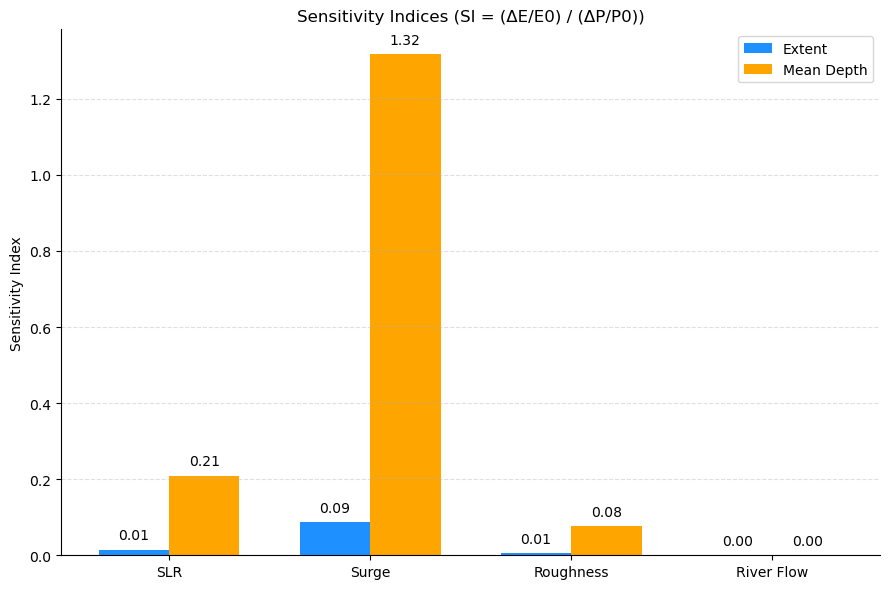

In [12]:
import os
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ====================== USER INPUTS ======================
THRESHOLD = 0.1  # meters; cells <= THRESHOLD are dry

# Boundary (GeoPandas can read zipped shapefile via "zip://")
boundary_zip = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Reference & perturbed rasters
ref_file   = r"D:\Phd Research\sim_depth_100yr.tif"

slr_minus  = r"D:\Phd Research\sim_depth_100yr_0.8SLR.tif"      # 20% less SLR
slr_plus   = r"D:\Phd Research\sim_depth_100yr_1.2SLR.tif"      # 20% more SLR

surge_minus = r"D:\Phd Research\sim_depth_100yr_surge_M10.tif"  # 10% less surge
surge_plus  = r"D:\Phd Research\sim_depth_100yr_surge_P10.tif"  # 10% more surge

rough_minus = r"D:\Phd Research\sim_depth_100yr_surge_M20_Mannings.tif" # 20% less Manning's M
rough_plus  = r"D:\Phd Research\sim_depth_100yr_surge_P20_Mannings.tif" # 20% more Manning's M

flow_minus  = r"D:\Phd Research\sim_depth_100yr_surge_Q_M20.tif" # 20% less inland discharge
flow_plus   = r"D:\Phd Research\sim_depth_100yr_surge_Q_P20.tif" # 20% more inland discharge

# Fractional parameter perturbations (ΔP/P0) for the ± experiments
DP_FRAC = {
    "SLR":        0.20,  # ±20%
    "Surge":      0.10,  # ±10%
    "Roughness":  0.20,  # ±20%
    "River Flow": 0.20,  # ±20%
}

TITLE = "Sensitivity Indices (SI = (ΔE/E0) / (ΔP/P0))"
# ========================================================

def read_boundary_from_zip(zip_path: str) -> gpd.GeoDataFrame:
    try:
        return gpd.read_file(f"zip://{zip_path}")
    except Exception:
        return gpd.read_file(zip_path)

def compute_extent_and_mean_depth(raster_path: str, boundary_gdf: gpd.GeoDataFrame, threshold: float):
    """
    Returns:
      extent_area_km2: flooded area in km² (cells with depth > threshold)
      mean_depth: mean flooded depth in meters (over cells with depth > threshold)
    """
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        data = out_img[0].astype("float64")
        nodata = src.nodata

    # mask invalid / dry
    m = np.zeros(data.shape, dtype=bool)
    if nodata is not None:
        m |= (data == nodata)
    m |= (~np.isfinite(data))  # NaN/Inf
    m |= (data < 0)            # negative depths invalid
    m |= (data <= threshold)   # dry cells

    masked = ma.array(data, mask=m)

    # pixel area (m²) -> extent area (km²)
    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h
    flooded_cells = masked.count()
    extent_area_km2 = (flooded_cells * cell_area_m2) / 1e6

    # mean flooded depth
    mean_depth = float(masked.mean()) if flooded_cells > 0 else 0.0
    return extent_area_km2, mean_depth

def si_ratio(E0: float, E_minus: float, E_plus: float, dp_frac: float) -> float:
    """
    SI = (ΔE/E0) / (ΔP/P0), with central difference ΔE = (E+ - E-)/2.
    Returns SI (unitless). Safe for E0 == 0 or dp_frac == 0 -> returns 0.0.
    """
    if E0 == 0 or dp_frac == 0:
        return 0.0
    dE = (E_plus - E_minus) / 2.0
    return (dE / E0) / dp_frac

# ------------------ MAIN ------------------
boundary = read_boundary_from_zip(boundary_zip)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Set CRS (e.g., EPSG:32614) before running.")

# Reference metrics
E0_extent, E0_depth = compute_extent_and_mean_depth(ref_file, boundary, THRESHOLD)
print(f"Reference: extent = {E0_extent:.3f} km² | mean depth = {E0_depth:.4f} m  (threshold > {THRESHOLD} m)")

drivers = {
    "SLR":        (slr_minus,  slr_plus,  DP_FRAC["SLR"]),
    "Surge":      (surge_minus, surge_plus, DP_FRAC["Surge"]),
    "Roughness":  (rough_minus, rough_plus, DP_FRAC["Roughness"]),
    "River Flow": (flow_minus,  flow_plus,  DP_FRAC["River Flow"]),
}

rows = []
for name, (f_minus, f_plus, dp) in drivers.items():
    E_minus_extent, E_minus_depth = compute_extent_and_mean_depth(f_minus, boundary, THRESHOLD)
    E_plus_extent,  E_plus_depth  = compute_extent_and_mean_depth(f_plus,  boundary, THRESHOLD)

    # SI for extent and mean depth using your formula
    si_extent = si_ratio(E0_extent, E_minus_extent, E_plus_extent, dp)
    si_depth  = si_ratio(E0_depth,  E_minus_depth,  E_plus_depth,  dp)

    # Full breakdown terms
    dE_extent = (E_plus_extent - E_minus_extent) / 2.0
    dE_depth  = (E_plus_depth  - E_minus_depth)  / 2.0
    frac_dE_over_E0_extent = (dE_extent / E0_extent) if E0_extent != 0 else 0.0
    frac_dE_over_E0_depth  = (dE_depth  / E0_depth)  if E0_depth  != 0 else 0.0
    frac_dP_over_P0 = dp  # by input (±k%)

    rows.append({
        "Driver": name,
        "SI_extent": si_extent,
        "SI_mean_depth": si_depth,
        "ΔE_extent": dE_extent,
        "ΔE_depth": dE_depth,
        "ΔE/E0_extent": frac_dE_over_E0_extent,
        "ΔE/E0_depth":  frac_dE_over_E0_depth,
        "ΔP/P0": frac_dP_over_P0,
        "Extent_minus_km2": E_minus_extent,
        "Extent_plus_km2":  E_plus_extent,
        "MeanDepth_minus_m": E_minus_depth,
        "MeanDepth_plus_m":  E_plus_depth,
    })

    # Verbose, step-by-step printout
    print(f"\n{name} (ΔP/P0 = {dp:.2f}):")
    print(f"  Extent:  E-={E_minus_extent:.3f}, E+={E_plus_extent:.3f}, ΔE={(dE_extent):.3f}, ΔE/E0={(frac_dE_over_E0_extent):.5f} -> SI={(si_extent):.3f}")
    print(f"  Depth:   E-={E_minus_depth:.4f}, E+={E_plus_depth:.4f}, ΔE={(dE_depth):.4f},  ΔE/E0={(frac_dE_over_E0_depth):.5f}  -> SI={(si_depth):.3f}")

df = pd.DataFrame(rows)
df = df[["Driver", "SI_extent", "SI_mean_depth",
         "ΔP/P0", "ΔE_extent", "ΔE/E0_extent",
         "ΔE_depth", "ΔE/E0_depth",
         "Extent_minus_km2", "Extent_plus_km2",
         "MeanDepth_minus_m", "MeanDepth_plus_m"]]

print("\n=== Sensitivity Index Summary (unitless SI = (ΔE/E0)/(ΔP/P0)) ===")
print(df.to_string(index=False))

# ---------- Plot (bars show SI, not %) ----------
labels = df["Driver"].tolist()
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
bars1 = ax.bar(x - width/2, df["SI_extent"], width, label="Extent", color="dodgerblue")
bars2 = ax.bar(x + width/2, df["SI_mean_depth"], width, label="Mean Depth", color="orange")

ax.set_ylabel("Sensitivity Index")
ax.set_title(TITLE)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# annotate bars
for bar in list(bars1) + list(bars2):
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0,
            y + (0.02 if y >= 0 else -0.04),
            f"{y:.2f}", ha="center", va="bottom" if y >= 0 else "top", fontsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

# save outputs
out_dir = Path.cwd()
csv_path = out_dir / "sensitivity_indices_ratio_formula.csv"
png_path = out_dir / "sensitivity_indices_ratio_formula.png"
df.to_csv(csv_path, index=False)
plt.savefig(png_path, dpi=300)
print(f"\nSaved table to: {csv_path}")
print(f"Saved figure to: {png_path}")

plt.show()


Reference: extent = 13752.880 km² | mean depth = 4.4071 m  (threshold > 0.1 m)

SLR (ΔP/P0 = 0.20):
  Extent:  E-=13698.240, E+=13795.760, ΔE=48.760, ΔE/E0=0.00355 -> SI=0.018
  Depth:   E-=4.1838, E+=4.6337, ΔE=0.2249,  ΔE/E0=0.05103  -> SI=0.255

Surge (ΔP/P0 = 0.10):
  Extent:  E-=13510.480, E+=13867.720, ΔE=178.620, ΔE/E0=0.01299 -> SI=0.130
  Depth:   E-=3.7098, E+=5.0955, ΔE=0.6928,  ΔE/E0=0.15721  -> SI=1.572

Roughness (ΔP/P0 = 0.20):
  Extent:  E-=13721.960, E+=13793.800, ΔE=35.920, ΔE/E0=0.00261 -> SI=0.013
  Depth:   E-=4.2083, E+=4.5747, ΔE=0.1832,  ΔE/E0=0.04157  -> SI=0.208

River Flow (ΔP/P0 = 0.20):
  Extent:  E-=13752.640, E+=13753.320, ΔE=0.340, ΔE/E0=0.00002 -> SI=0.000
  Depth:   E-=4.4039, E+=4.4102, ΔE=0.0032,  ΔE/E0=0.00072  -> SI=0.004

=== Sensitivity Index Summary (unitless SI = (ΔE/E0)/(ΔP/P0)) ===
    Driver  SI_extent  SI_mean_depth  ΔP/P0  ΔE_extent  ΔE/E0_extent  ΔE_depth  ΔE/E0_depth  Extent_minus_km2  Extent_plus_km2  MeanDepth_minus_m  MeanDepth_plus_m

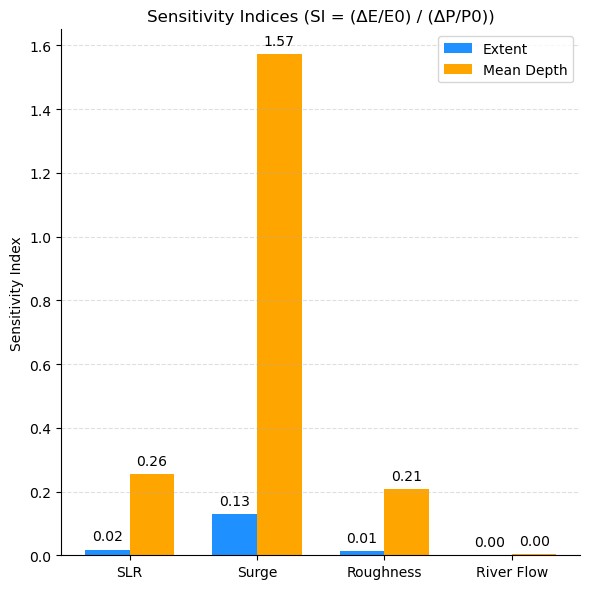

In [2]:
import os
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ====================== USER INPUTS ======================
THRESHOLD = 0.1  # meters; cells <= THRESHOLD are dry

# Boundary (GeoPandas can read zipped shapefile via "zip://")
boundary_zip = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Reference & perturbed rasters
ref_file   = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"

slr_minus  = r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_M20_stat.tif"      # 20% less SLR
slr_plus   = r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_P20_stat.tif"      # 20% more SLR

surge_minus = r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_M10_stat.tif"  # 10% less surge
surge_plus  = r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_P10_stat.tif"  # 10% more surge

rough_minus = r"D:\Phd Research\Final_Raster\100yr_compound_flood_M_M20_stat.tif" # 20% less Manning's M
rough_plus  = r"D:\Phd Research\Final_Raster\100yr_Compound_flood_base_M_P20_stat.tif"# 20% more Manning's M

flow_minus  = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_M20_stat.tif" # 20% less inland discharge
flow_plus   = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_P_20_stat.tif" # 20% more inland discharge

# Fractional parameter perturbations (ΔP/P0) for the ± experiments
DP_FRAC = {
    "SLR":        0.20,  # ±20%
    "Surge":      0.10,  # ±10%
    "Roughness":  0.20,  # ±20%
    "River Flow": 0.20,  # ±20%
}

TITLE = "Sensitivity Indices (SI = (ΔE/E0) / (ΔP/P0))"
# ========================================================

def read_boundary_from_zip(zip_path: str) -> gpd.GeoDataFrame:
    try:
        return gpd.read_file(f"zip://{zip_path}")
    except Exception:
        return gpd.read_file(zip_path)

def compute_extent_and_mean_depth(raster_path: str, boundary_gdf: gpd.GeoDataFrame, threshold: float):
    """
    Returns:
      extent_area_km2: flooded area in km² (cells with depth > threshold)
      mean_depth: mean flooded depth in meters (over cells with depth > threshold)
    """
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        data = out_img[0].astype("float64")
        nodata = src.nodata

    # mask invalid / dry
    m = np.zeros(data.shape, dtype=bool)
    if nodata is not None:
        m |= (data == nodata)
    m |= (~np.isfinite(data))  # NaN/Inf
    m |= (data < 0)            # negative depths invalid
    m |= (data <= threshold)   # dry cells

    masked = ma.array(data, mask=m)

    # pixel area (m²) -> extent area (km²)
    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h
    flooded_cells = masked.count()
    extent_area_km2 = (flooded_cells * cell_area_m2) / 1e6

    # mean flooded depth
    mean_depth = float(masked.mean()) if flooded_cells > 0 else 0.0
    return extent_area_km2, mean_depth

def si_ratio(E0: float, E_minus: float, E_plus: float, dp_frac: float) -> float:
    """
    SI = (ΔE/E0) / (ΔP/P0), with central difference ΔE = (E+ - E-)/2.
    Returns SI (unitless). Safe for E0 == 0 or dp_frac == 0 -> returns 0.0.
    """
    if E0 == 0 or dp_frac == 0:
        return 0.0
    dE = (E_plus - E_minus) / 2.0
    return (dE / E0) / dp_frac

# ------------------ MAIN ------------------
boundary = read_boundary_from_zip(boundary_zip)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Set CRS (e.g., EPSG:32614) before running.")

# Reference metrics
E0_extent, E0_depth = compute_extent_and_mean_depth(ref_file, boundary, THRESHOLD)
print(f"Reference: extent = {E0_extent:.3f} km² | mean depth = {E0_depth:.4f} m  (threshold > {THRESHOLD} m)")

drivers = {
    "SLR":        (slr_minus,  slr_plus,  DP_FRAC["SLR"]),
    "Surge":      (surge_minus, surge_plus, DP_FRAC["Surge"]),
    "Roughness":  (rough_minus, rough_plus, DP_FRAC["Roughness"]),
    "River Flow": (flow_minus,  flow_plus,  DP_FRAC["River Flow"]),
}

rows = []
for name, (f_minus, f_plus, dp) in drivers.items():
    E_minus_extent, E_minus_depth = compute_extent_and_mean_depth(f_minus, boundary, THRESHOLD)
    E_plus_extent,  E_plus_depth  = compute_extent_and_mean_depth(f_plus,  boundary, THRESHOLD)

    # SI for extent and mean depth using your formula
    si_extent = si_ratio(E0_extent, E_minus_extent, E_plus_extent, dp)
    si_depth  = si_ratio(E0_depth,  E_minus_depth,  E_plus_depth,  dp)

    # Full breakdown terms
    dE_extent = (E_plus_extent - E_minus_extent) / 2.0
    dE_depth  = (E_plus_depth  - E_minus_depth)  / 2.0
    frac_dE_over_E0_extent = (dE_extent / E0_extent) if E0_extent != 0 else 0.0
    frac_dE_over_E0_depth  = (dE_depth  / E0_depth)  if E0_depth  != 0 else 0.0
    frac_dP_over_P0 = dp  # by input (±k%)

    rows.append({
        "Driver": name,
        "SI_extent": si_extent,
        "SI_mean_depth": si_depth,
        "ΔE_extent": dE_extent,
        "ΔE_depth": dE_depth,
        "ΔE/E0_extent": frac_dE_over_E0_extent,
        "ΔE/E0_depth":  frac_dE_over_E0_depth,
        "ΔP/P0": frac_dP_over_P0,
        "Extent_minus_km2": E_minus_extent,
        "Extent_plus_km2":  E_plus_extent,
        "MeanDepth_minus_m": E_minus_depth,
        "MeanDepth_plus_m":  E_plus_depth,
    })

    # Verbose, step-by-step printout
    print(f"\n{name} (ΔP/P0 = {dp:.2f}):")
    print(f"  Extent:  E-={E_minus_extent:.3f}, E+={E_plus_extent:.3f}, ΔE={(dE_extent):.3f}, ΔE/E0={(frac_dE_over_E0_extent):.5f} -> SI={(si_extent):.3f}")
    print(f"  Depth:   E-={E_minus_depth:.4f}, E+={E_plus_depth:.4f}, ΔE={(dE_depth):.4f},  ΔE/E0={(frac_dE_over_E0_depth):.5f}  -> SI={(si_depth):.3f}")

df = pd.DataFrame(rows)
df = df[["Driver", "SI_extent", "SI_mean_depth",
         "ΔP/P0", "ΔE_extent", "ΔE/E0_extent",
         "ΔE_depth", "ΔE/E0_depth",
         "Extent_minus_km2", "Extent_plus_km2",
         "MeanDepth_minus_m", "MeanDepth_plus_m"]]

print("\n=== Sensitivity Index Summary (unitless SI = (ΔE/E0)/(ΔP/P0)) ===")
print(df.to_string(index=False))

# ---------- Plot (bars show SI, not %) ----------
labels = df["Driver"].tolist()
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 6))
bars1 = ax.bar(x - width/2, df["SI_extent"], width, label="Extent", color="dodgerblue")
bars2 = ax.bar(x + width/2, df["SI_mean_depth"], width, label="Mean Depth", color="orange")

ax.set_ylabel("Sensitivity Index")
ax.set_title(TITLE)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# annotate bars
for bar in list(bars1) + list(bars2):
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0,
            y + (0.02 if y >= 0 else -0.04),
            f"{y:.2f}", ha="center", va="bottom" if y >= 0 else "top", fontsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

# save outputs
out_dir = Path.cwd()
csv_path = out_dir / "sensitivity_indices_ratio_formula.csv"
png_path = out_dir / "sensitivity_indices_ratio_formula.png"
df.to_csv(csv_path, index=False)
plt.savefig(png_path, dpi=300)
print(f"\nSaved table to: {csv_path}")
print(f"Saved figure to: {png_path}")

plt.show()


Reference: extent = 13752.880 km² | mean depth = 4.4071 m  (threshold > 0.1 m)

Saved table to: C:\Users\sahad2\sensitivity_indices_ratio_formula.csv
Saved figure to: C:\Users\sahad2\sensitivity_indices_ratio_formula.png


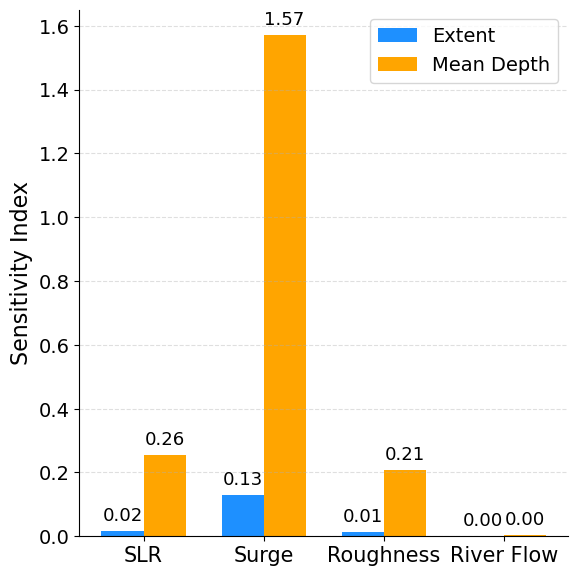

In [5]:
import os
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ====================== USER INPUTS ======================
THRESHOLD = 0.1  # meters; cells <= THRESHOLD are dry

# Boundary (GeoPandas can read zipped shapefile via "zip://")
boundary_zip = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Reference & perturbed rasters
ref_file   = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"

slr_minus  = r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_M20_stat.tif"
slr_plus   = r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_P20_stat.tif"
surge_minus = r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_M10_stat.tif"
surge_plus  = r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_P10_stat.tif"
rough_minus = r"D:\Phd Research\Final_Raster\100yr_compound_flood_M_M20_stat.tif"
rough_plus  = r"D:\Phd Research\Final_Raster\100yr_Compound_flood_base_M_P20_stat.tif"
flow_minus  = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_M20_stat.tif"
flow_plus   = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_P_20_stat.tif"

# Fractional parameter perturbations (ΔP/P0) for ± experiments
DP_FRAC = {"SLR": 0.20, "Surge": 0.10, "Roughness": 0.20, "River Flow": 0.20}

# TITLE = "Sensitivity Indices (SI = (ΔE/E0) / (ΔP/P0))"
# ========================================================

plt.rcParams.update({
    'font.size': 14,        # base font size
    'axes.titlesize': 18,   # plot title
    'axes.labelsize': 16,   # axis labels
    'xtick.labelsize': 14,  # tick labels
    'ytick.labelsize': 14,
    'legend.fontsize': 14,  # legend
})

def read_boundary_from_zip(zip_path: str) -> gpd.GeoDataFrame:
    try:
        return gpd.read_file(f"zip://{zip_path}")
    except Exception:
        return gpd.read_file(zip_path)

def compute_extent_and_mean_depth(raster_path: str, boundary_gdf: gpd.GeoDataFrame, threshold: float):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        data = out_img[0].astype("float64")
        nodata = src.nodata

    m = np.zeros(data.shape, dtype=bool)
    if nodata is not None:
        m |= (data == nodata)
    m |= (~np.isfinite(data))
    m |= (data < 0)
    m |= (data <= threshold)

    masked = ma.array(data, mask=m)
    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h
    flooded_cells = masked.count()
    extent_area_km2 = (flooded_cells * cell_area_m2) / 1e6
    mean_depth = float(masked.mean()) if flooded_cells > 0 else 0.0
    return extent_area_km2, mean_depth

def si_ratio(E0: float, E_minus: float, E_plus: float, dp_frac: float) -> float:
    if E0 == 0 or dp_frac == 0:
        return 0.0
    dE = (E_plus - E_minus) / 2.0
    return (dE / E0) / dp_frac

boundary = read_boundary_from_zip(boundary_zip)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Set CRS (e.g., EPSG:32614) before running.")

E0_extent, E0_depth = compute_extent_and_mean_depth(ref_file, boundary, THRESHOLD)
print(f"Reference: extent = {E0_extent:.3f} km² | mean depth = {E0_depth:.4f} m  (threshold > {THRESHOLD} m)")

drivers = {
    "SLR": (slr_minus, slr_plus, DP_FRAC["SLR"]),
    "Surge": (surge_minus, surge_plus, DP_FRAC["Surge"]),
    "Roughness": (rough_minus, rough_plus, DP_FRAC["Roughness"]),
    "River Flow": (flow_minus, flow_plus, DP_FRAC["River Flow"]),
}

rows = []
for name, (f_minus, f_plus, dp) in drivers.items():
    E_minus_extent, E_minus_depth = compute_extent_and_mean_depth(f_minus, boundary, THRESHOLD)
    E_plus_extent,  E_plus_depth  = compute_extent_and_mean_depth(f_plus,  boundary, THRESHOLD)
    si_extent = si_ratio(E0_extent, E_minus_extent, E_plus_extent, dp)
    si_depth  = si_ratio(E0_depth,  E_minus_depth,  E_plus_depth,  dp)
    dE_extent = (E_plus_extent - E_minus_extent) / 2.0
    dE_depth  = (E_plus_depth  - E_minus_depth)  / 2.0
    frac_dE_over_E0_extent = (dE_extent / E0_extent) if E0_extent != 0 else 0.0
    frac_dE_over_E0_depth  = (dE_depth  / E0_depth)  if E0_depth  != 0 else 0.0

    rows.append({
        "Driver": name,
        "SI_extent": si_extent,
        "SI_mean_depth": si_depth,
    })

df = pd.DataFrame(rows)
labels = df["Driver"].tolist()
x = np.arange(len(labels))
width = 0.35

# ---------- Plot (larger text) ----------
fig, ax = plt.subplots(figsize=(6, 6))
bars1 = ax.bar(x - width/2, df["SI_extent"], width, label="Extent", color="dodgerblue")
bars2 = ax.bar(x + width/2, df["SI_mean_depth"], width, label="Mean Depth", color="orange")

ax.set_ylabel("Sensitivity Index", fontsize=16)
# ax.set_xlabel("Flood Driver", fontsize=16)
# ax.set_title(TITLE, fontsize=18, weight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=15)
ax.legend(fontsize=14, loc="upper right")

for bar in list(bars1) + list(bars2):
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0,
            y + (0.02 if y >= 0 else -0.04),
            f"{y:.2f}", ha="center", va="bottom" if y >= 0 else "top", fontsize=13)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

# Save outputs
out_dir = Path.cwd()
csv_path = out_dir / "sensitivity_indices_ratio_formula.csv"
png_path = out_dir / "sensitivity_indices_ratio_formula.png"
df.to_csv(csv_path, index=False)
plt.savefig(png_path, dpi=300)
print(f"\nSaved table to: {csv_path}")
print(f"Saved figure to: {png_path}")

plt.show()


Reference: extent = 13752.880 km² | mean depth = 4.4071 m  (threshold > 0.1 m)

Saved table to: C:\Users\sahad2\sensitivity_indices_ratio_formula.csv
Saved figure to: C:\Users\sahad2\sensitivity_indices_ratio_formula.png


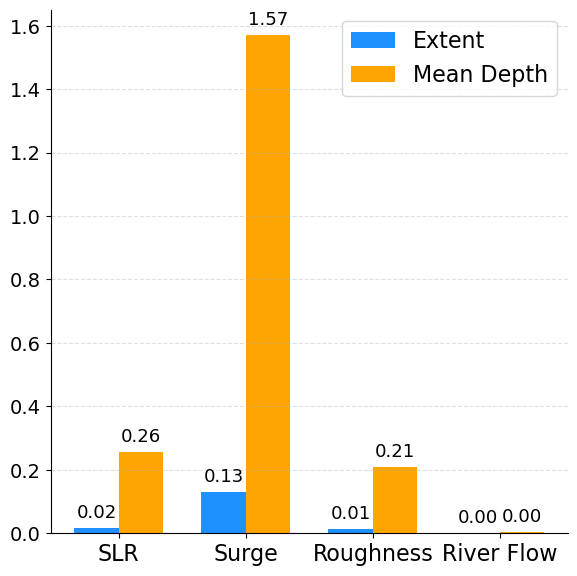

In [1]:
import os
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ====================== USER INPUTS ======================
THRESHOLD = 0.1  # meters; cells <= THRESHOLD are dry

# Boundary (GeoPandas can read zipped shapefile via "zip://")
boundary_zip = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Reference & perturbed rasters
ref_file   = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"

slr_minus  = r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_M20_stat.tif"
slr_plus   = r"D:\Phd Research\Final_Raster\100yr_compound_flood_SLR_P20_stat.tif"
surge_minus = r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_M10_stat.tif"
surge_plus  = r"D:\Phd Research\Final_Raster\100yr_compound_flood_surge_P10_stat.tif"
rough_minus = r"D:\Phd Research\Final_Raster\100yr_compound_flood_M_M20_stat.tif"
rough_plus  = r"D:\Phd Research\Final_Raster\100yr_Compound_flood_base_M_P20_stat.tif"
flow_minus  = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_M20_stat.tif"
flow_plus   = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_P_20_stat.tif"

# Fractional parameter perturbations (ΔP/P0) for ± experiments
DP_FRAC = {"SLR": 0.20, "Surge": 0.10, "Roughness": 0.20, "River Flow": 0.20}

# TITLE = "Sensitivity Indices (SI = (ΔE/E0) / (ΔP/P0))"
# ========================================================

plt.rcParams.update({
    'font.size': 14,        # base font size
    'axes.titlesize': 18,   # plot title
    'axes.labelsize': 16,   # axis labels
    'xtick.labelsize': 14,  # tick labels
    'ytick.labelsize': 14,
    'legend.fontsize': 14,  # legend
})

def read_boundary_from_zip(zip_path: str) -> gpd.GeoDataFrame:
    try:
        return gpd.read_file(f"zip://{zip_path}")
    except Exception:
        return gpd.read_file(zip_path)

def compute_extent_and_mean_depth(raster_path: str, boundary_gdf: gpd.GeoDataFrame, threshold: float):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster CRS is None for: {raster_path}")
        boundary_proj = boundary_gdf.to_crs(src.crs)
        out_img, out_transform = mask(src, boundary_proj.geometry, crop=True)
        data = out_img[0].astype("float64")
        nodata = src.nodata

    m = np.zeros(data.shape, dtype=bool)
    if nodata is not None:
        m |= (data == nodata)
    m |= (~np.isfinite(data))
    m |= (data < 0)
    m |= (data <= threshold)

    masked = ma.array(data, mask=m)
    px_w = abs(out_transform.a)
    px_h = abs(out_transform.e)
    cell_area_m2 = px_w * px_h
    flooded_cells = masked.count()
    extent_area_km2 = (flooded_cells * cell_area_m2) / 1e6
    mean_depth = float(masked.mean()) if flooded_cells > 0 else 0.0
    return extent_area_km2, mean_depth

def si_ratio(E0: float, E_minus: float, E_plus: float, dp_frac: float) -> float:
    if E0 == 0 or dp_frac == 0:
        return 0.0
    dE = (E_plus - E_minus) / 2.0
    return (dE / E0) / dp_frac

boundary = read_boundary_from_zip(boundary_zip)
if boundary.crs is None:
    raise ValueError("Boundary CRS is None. Set CRS (e.g., EPSG:32614) before running.")

E0_extent, E0_depth = compute_extent_and_mean_depth(ref_file, boundary, THRESHOLD)
print(f"Reference: extent = {E0_extent:.3f} km² | mean depth = {E0_depth:.4f} m  (threshold > {THRESHOLD} m)")

drivers = {
    "SLR": (slr_minus, slr_plus, DP_FRAC["SLR"]),
    "Surge": (surge_minus, surge_plus, DP_FRAC["Surge"]),
    "Roughness": (rough_minus, rough_plus, DP_FRAC["Roughness"]),
    "River Flow": (flow_minus, flow_plus, DP_FRAC["River Flow"]),
}

rows = []
for name, (f_minus, f_plus, dp) in drivers.items():
    E_minus_extent, E_minus_depth = compute_extent_and_mean_depth(f_minus, boundary, THRESHOLD)
    E_plus_extent,  E_plus_depth  = compute_extent_and_mean_depth(f_plus,  boundary, THRESHOLD)
    si_extent = si_ratio(E0_extent, E_minus_extent, E_plus_extent, dp)
    si_depth  = si_ratio(E0_depth,  E_minus_depth,  E_plus_depth,  dp)
    dE_extent = (E_plus_extent - E_minus_extent) / 2.0
    dE_depth  = (E_plus_depth  - E_minus_depth)  / 2.0
    frac_dE_over_E0_extent = (dE_extent / E0_extent) if E0_extent != 0 else 0.0
    frac_dE_over_E0_depth  = (dE_depth  / E0_depth)  if E0_depth  != 0 else 0.0

    rows.append({
        "Driver": name,
        "SI_extent": si_extent,
        "SI_mean_depth": si_depth,
    })

df = pd.DataFrame(rows)
labels = df["Driver"].tolist()
x = np.arange(len(labels))
width = 0.35

# ---------- Plot (larger text) ----------
fig, ax = plt.subplots(figsize=(6, 6))
bars1 = ax.bar(x - width/2, df["SI_extent"], width, label="Extent", color="dodgerblue")
bars2 = ax.bar(x + width/2, df["SI_mean_depth"], width, label="Mean Depth", color="orange")

#ax.set_ylabel("Sensitivity Index", fontsize=16)
# ax.set_xlabel("Flood Driver", fontsize=16)
# ax.set_title(TITLE, fontsize=18, weight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=16)
ax.legend(fontsize=16, loc="upper right")

for bar in list(bars1) + list(bars2):
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0,
            y + (0.02 if y >= 0 else -0.04),
            f"{y:.2f}", ha="center", va="bottom" if y >= 0 else "top", fontsize=13)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

# Save outputs
out_dir = Path.cwd()
csv_path = out_dir / "sensitivity_indices_ratio_formula.csv"
png_path = out_dir / "sensitivity_indices_ratio_formula.png"
df.to_csv(csv_path, index=False)
plt.savefig(png_path, dpi=300)
print(f"\nSaved table to: {csv_path}")
print(f"Saved figure to: {png_path}")

plt.show()
